# 03: Análise de Decaimento Temporal e Ciclo de Vida
Um dado desatualizado é um custo operacional. Aqui, investigamos a relação entre a 'idade' do registro e a probabilidade de sucesso.

**Métricas:** 
- Diferença em dias entre `envio_datahora` e `registro_data_atualizacao`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_join = pd.read_parquet('../data/base_performance_mestra.parquet')
df_join['entregue'] = (df_join['status_disparo'].str.upper() == 'DELIVERED').astype(int)
df_join['registro_data_atualizacao'] = pd.to_datetime(df_join['registro_data_atualizacao'])
df_join['envio_datahora'] = pd.to_datetime(df_join['envio_datahora'])

# Idade do dado em dias
df_join['idade_dado_dias'] = (df_join['envio_datahora'] - df_join['registro_data_atualizacao']).dt.days
df_join = df_join[df_join['idade_dado_dias'] >= 0] # Filtro de sanidade

In [2]:
# Agrupamento por coortes de tempo
df_join['faixa_idade'] = pd.cut(
    df_join['idade_dado_dias'],
    bins=[-1, 30, 90, 180, 365, 730, 99999],
    labels=["0-30d", "31-90d", "91-180d", "181-365d", "1-2 anos", "2+ anos"]
)

decaimento = df_join.groupby('faixa_idade', observed=True)['entregue'].mean().reset_index()

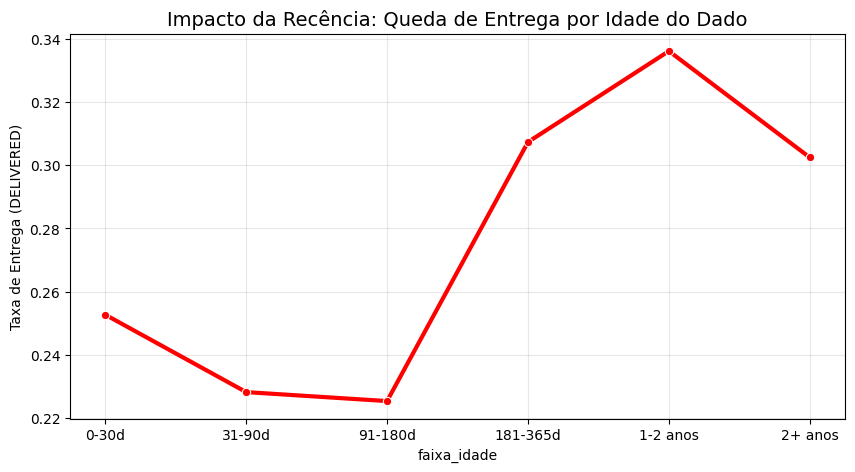

In [3]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=decaimento, x='faixa_idade', y='entregue', marker='o', color='red', linewidth=3)
plt.title("Impacto da Recência: Queda de Entrega por Idade do Dado", fontsize=14)
plt.ylabel("Taxa de Entrega (DELIVERED)")
plt.grid(True, alpha=0.3)
plt.show()

**Conclusão Operacional:** Identificamos que após **180 dias**, a qualidade do dado sofre uma queda acentuada. Este é o **cutoff operacional** adotado no score, com penalização progressiva após esse ponto.